**Load the Dataset**

In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("imdb-movies-dataset.csv")
df.head()

,Poster,Title,Year,Certificate,Duration,Genre,Rating,Metascore,Director,Cast,VotesCount,Description,ReviewCount,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


In [243]:
df.shape

(10000, 15)

Data Preprocessing

In [244]:
df.isnull().sum()
df = df.dropna() 
df.columns = df.columns.str.strip()

remove dublicts

In [245]:

duplicate_count = df.duplicated(subset='Title').sum()
duplicate_count

np.int64(159)

In [246]:
df = df.drop_duplicates(subset='Title', keep='first')
duplicate_count = df.duplicated(subset='Title').sum()
print(duplicate_count)
df.shape

0


(6245, 15)

Convert data types

In [247]:
df['VotesCount'] = df['VotesCount'].str.replace(',', '', regex=False).astype(int)
df['ReviewCount'] = df['ReviewCount'].str.replace(',', '', regex=False).astype(int)
df['Year'] = df['Year'].astype(int)
df['Rating'] = df['Rating'].astype(float)
df['Metascore'] = df['Metascore'].astype(int)
df['Duration'] = df['Duration'].astype(int)
df['Title'] = df['Title'].astype(str)
df['Certificate'] = pd.to_numeric(df['Certificate'].astype(str).str.replace(',', ''), errors='coerce').fillna(0).astype(int)


**Data Visualization**


**Pairplots using seaborn**

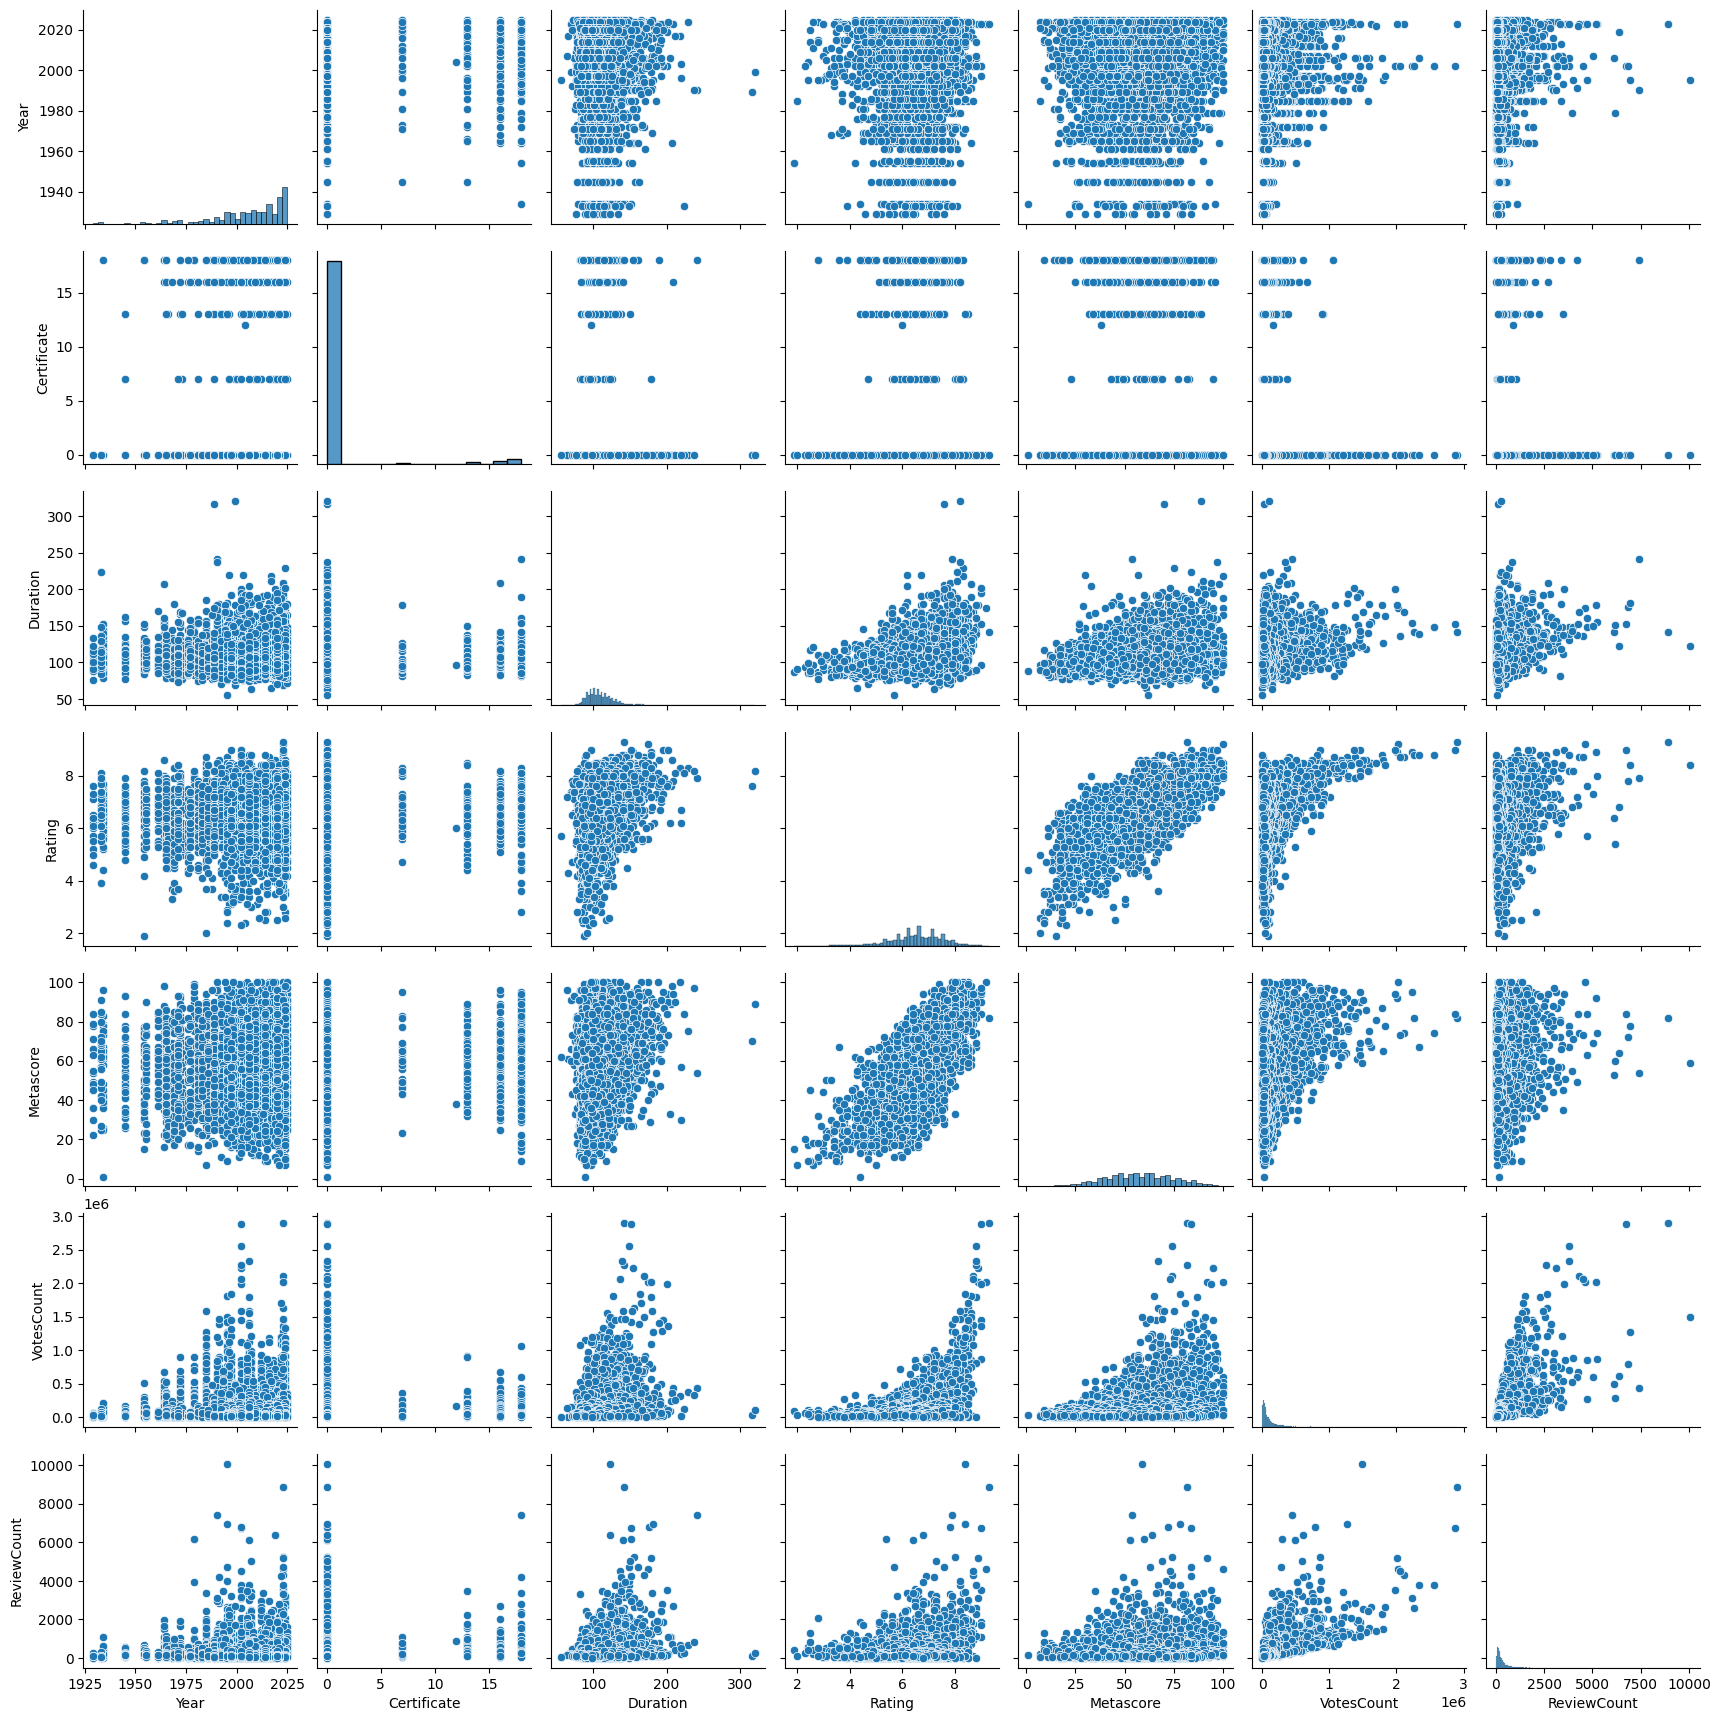

In [248]:
sns.pairplot(df)
plt.show()

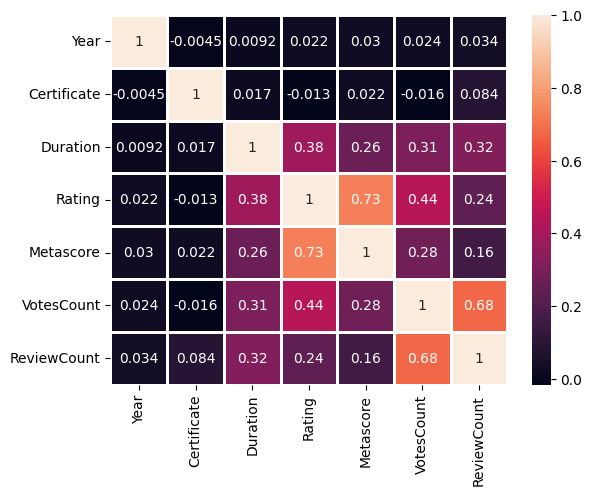

In [249]:
numeric_df=df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()
sns.heatmap(numeric_df.corr(),annot=True,linewidths=1)
plt.show()

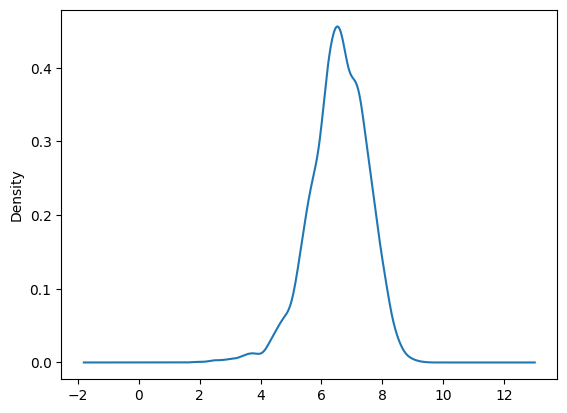

In [250]:
df['Rating'].plot.density()
plt.show()

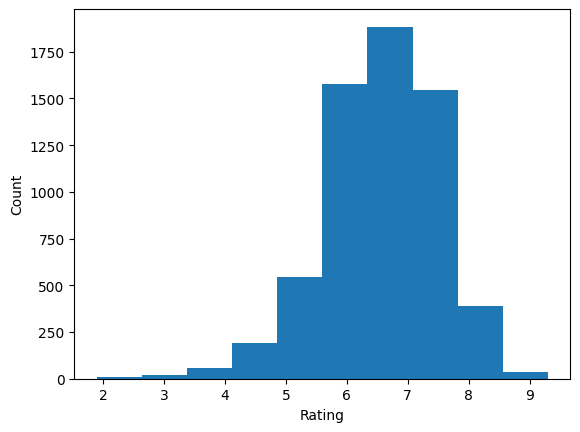

In [251]:


plt.hist(df['Rating'],)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


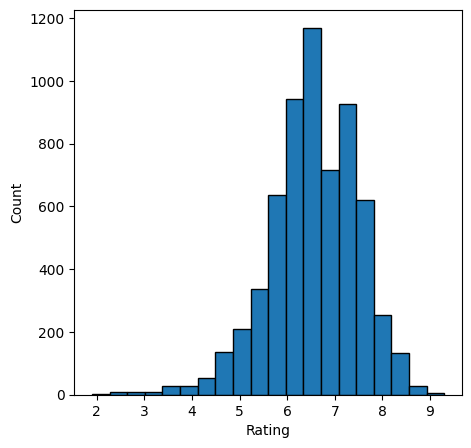

In [252]:
df['Rating'].plot.hist(bins=20,figsize=(5,5),edgecolor='k',)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


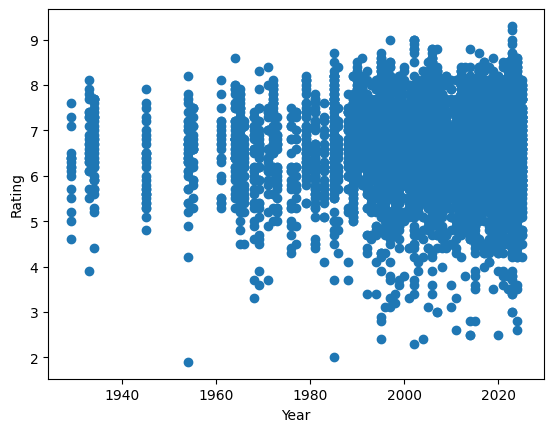

In [253]:
#display relation between rating and year
plt.scatter(df['Year'], df['Rating'])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

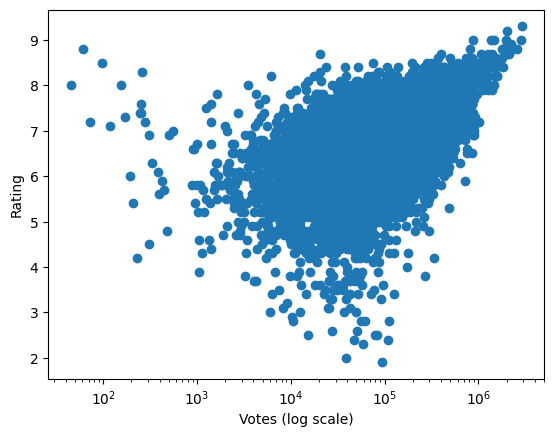

In [254]:
#display relation between rating and Votes
plt.scatter(df['VotesCount'], df['Rating'])
plt.xscale("log")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.show()

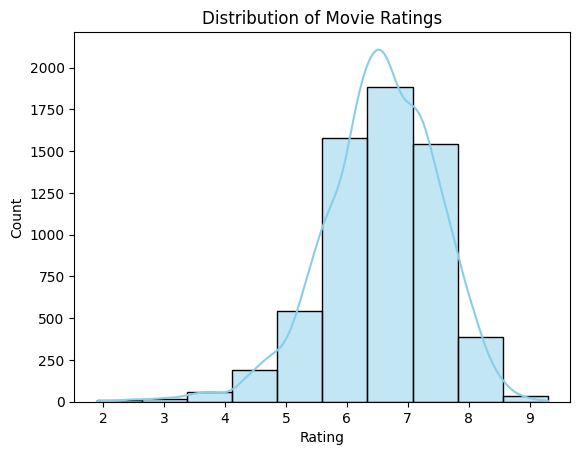

In [255]:
#display rating intervals with seaborn 
import seaborn as sns
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.xlabel("Rating")     
plt.ylabel("Count")      
plt.title("Distribution of Movie Ratings") 
plt.show()

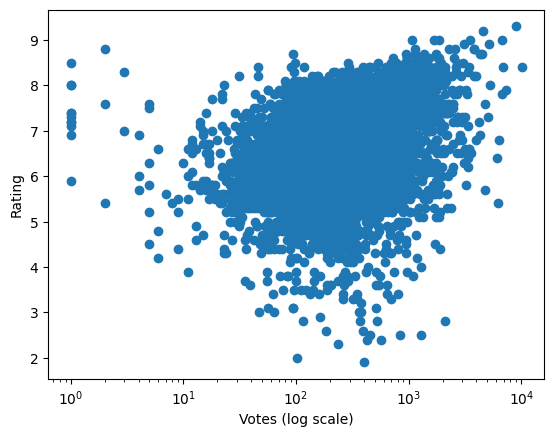

In [256]:

#display relation between rating and ReviewCount
plt.scatter(df['ReviewCount'], df['Rating'])
plt.xscale("log")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.show()

handle outliers

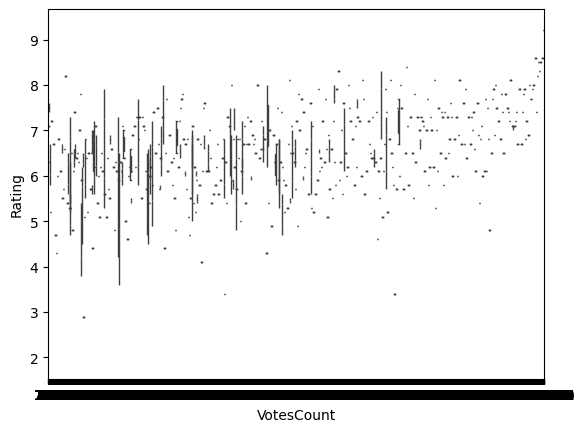

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['VotesCount'],y=df['Rating'])
plt.show()

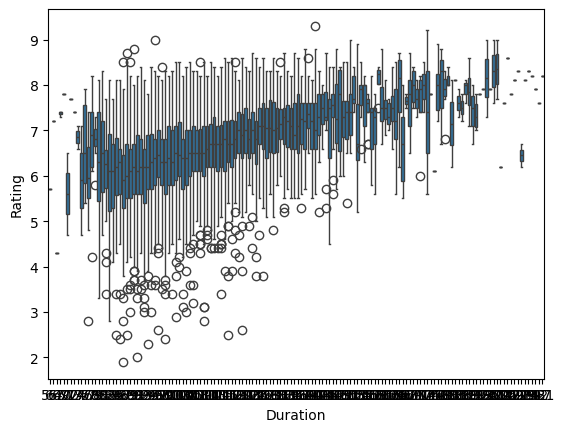

In [258]:

sns.boxplot(x=df['Duration'],y=df['Rating'])
plt.show()

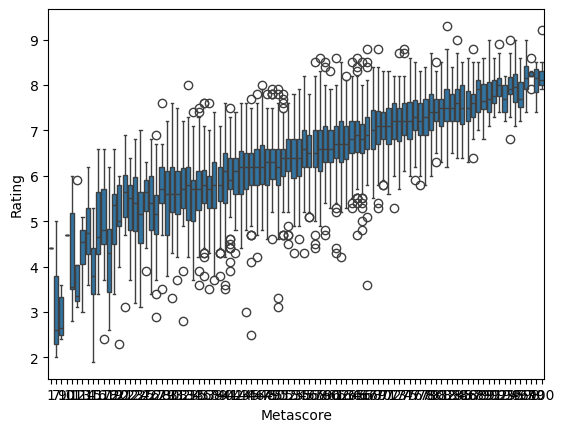

In [259]:
sns.boxplot(x=df['Metascore'],y=df['Rating'])
plt.show()

**Remove Outliers**

In [ ]:
chossen_cols = ['Metascore','VotesCount','Duration','Year','ReviewCount']
df_clean = df.copy()

for col in chossen_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

after remove outliers

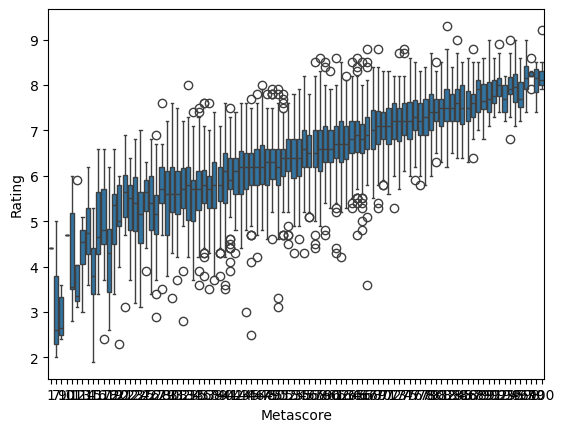

In [261]:
sns.boxplot(x=df_clean['Metascore'], y=df_clean['Rating'])
plt.show()

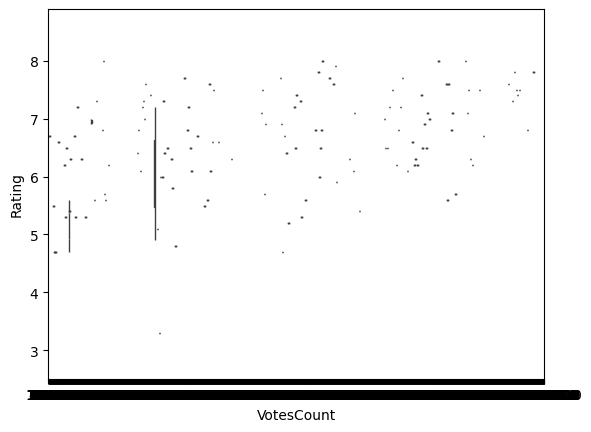

In [262]:
sns.boxplot(x=df_clean.sample(2000)['VotesCount'], y=df_clean.sample(2000)['Rating'])
plt.show()

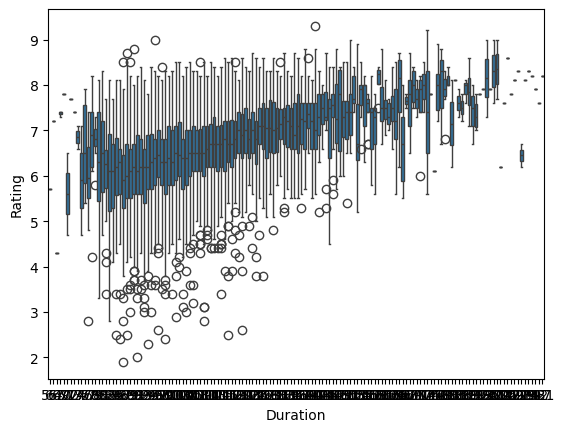

In [263]:
sns.boxplot(x=df_clean['Duration'], y=df_clean['Rating'])
plt.show()

In [264]:
df_clean.shape

(6245, 15)

### Feature Selection

In [265]:
#X = df_clean[['Metascore','VotesCount','Duration','Year','ReviewCount','Certificate']].copy()
X = df_clean[['Metascore','VotesCount','Duration','Year','ReviewCount']].copy()
y = df_clean['Rating']
X.shape
X.sample(10,ignore_index=False)

,Metascore,VotesCount,Duration,Year,ReviewCount
8925,34,15219,98,1998,51
5672,46,102223,85,2007,112
5114,62,43194,114,2020,150
2858,64,202182,121,1954,506
4764,39,161382,88,2015,213
4720,71,25883,112,2023,176
3662,45,277659,92,2004,337
7986,93,17790,73,1971,80
5635,63,76155,90,1995,88
4067,57,2191,117,2023,17


**Handle skewed numeric columns (log-transform Votes & ReviewCount)**

In [266]:
X['VotesCount'] = np.log1p(X['VotesCount'])
X['ReviewCount'] = np.log1p(X['ReviewCount'])



### Model fit and training using LinearRegression

**Import linear regression model estimator from scikit-learn and instantiate**

In [267]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [268]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [269]:
##train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Evaluate**

In [270]:
from sklearn.metrics import mean_squared_error

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:",rmse)

MSE: 0.3269018953981501
RMSE: 0.5717533518906122


In [271]:
r2 = metrics.r2_score(y_test, pred)
print("R-squared value of this fit:", round(r2, 3))

R-squared value of this fit: 0.631


### Model fit and training using Random Forest

In [272]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
     random_state=42,n_estimators=300,max_depth=50,min_samples_split=2,min_samples_leaf=11)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=50, min_samples_leaf=11, n_estimators=300,
                      random_state=42)

In [273]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

In [274]:

def mse():
    mse_training = metrics.mean_squared_error(y_train, y_pred_train)
    rmse_training = np.sqrt(mse_training)
    r2_training = metrics.r2_score(y_train, y_pred_train)

    print("Training Results:")
    print(f"MSE (train): {mse_training:.3f}")
    print(f"RMSE (train): {rmse_training:.3f}")
    print(f"R² (train): {r2_training:.3f}")


    mse_test = metrics.mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = metrics.r2_score(y_test, y_pred_test)

    print("\nTesting Results:")
    print(f"MSE (test): {mse_test:.3f}")
    print(f"RMSE (test): {rmse_test:.3f}")
    print(f"R² (test): {r2_test:.3f}")
mse()    

Training Results:
MSE (train): 0.215
RMSE (train): 0.464
R² (train): 0.752

Testing Results:
MSE (test): 0.324
RMSE (test): 0.569
R² (test): 0.634


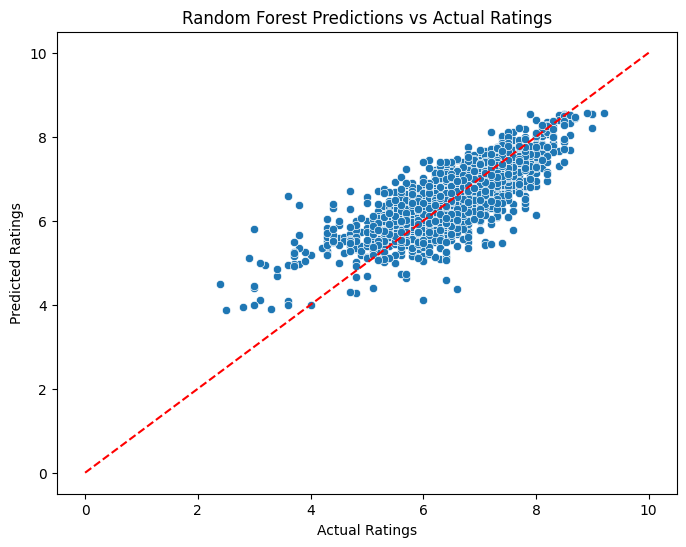

In [275]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest Predictions vs Actual Ratings")
plt.plot([0,10], [0,10], color='red', linestyle='--')  
plt.show()

In [276]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("",scores.mean())

 0.5911833846499145


Feature Importance

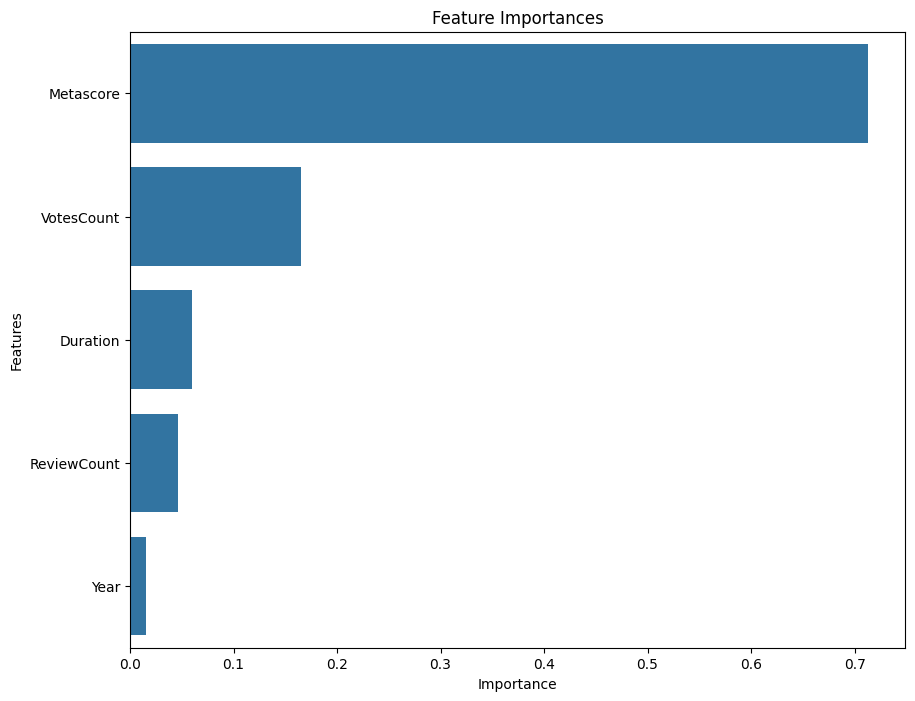

In [277]:
importances = rf.feature_importances_
feature_names = X.columns

sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(10,8))
sns.barplot(x=importances[sorted_idx], y=feature_names[sorted_idx])
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

**KNN Algorithm**

In [279]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


best_r2 = -1
best_k = None

for k in range(1, 200):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"K={k}, R²={r2:.3f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_k = k

print("\nBest K:", best_k)
print("Best R²:", best_r2)


K=1, R²=0.308
K=2, R²=0.473
K=3, R²=0.523
K=4, R²=0.560
K=5, R²=0.580
K=6, R²=0.594
K=7, R²=0.600
K=8, R²=0.604
K=9, R²=0.607
K=10, R²=0.610
K=11, R²=0.612
K=12, R²=0.614
K=13, R²=0.613
K=14, R²=0.614
K=15, R²=0.612
K=16, R²=0.612
K=17, R²=0.611
K=18, R²=0.610
K=19, R²=0.610
K=20, R²=0.609
K=21, R²=0.608
K=22, R²=0.610
K=23, R²=0.610
K=24, R²=0.610
K=25, R²=0.610
K=26, R²=0.609
K=27, R²=0.610
K=28, R²=0.611
K=29, R²=0.612
K=30, R²=0.612
K=31, R²=0.612
K=32, R²=0.611
K=33, R²=0.611
K=34, R²=0.610
K=35, R²=0.610
K=36, R²=0.609
K=37, R²=0.610
K=38, R²=0.610
K=39, R²=0.610
K=40, R²=0.610
K=41, R²=0.609
K=42, R²=0.609
K=43, R²=0.609
K=44, R²=0.608
K=45, R²=0.608
K=46, R²=0.607
K=47, R²=0.606
K=48, R²=0.606
K=49, R²=0.606
K=50, R²=0.606
K=51, R²=0.606
K=52, R²=0.606
K=53, R²=0.605
K=54, R²=0.605
K=55, R²=0.605
K=56, R²=0.604
K=57, R²=0.604
K=58, R²=0.603
K=59, R²=0.603
K=60, R²=0.603
K=61, R²=0.603
K=62, R²=0.602
K=63, R²=0.602
K=64, R²=0.602
K=65, R²=0.602
K=66, R²=0.602
K=67, R²=0.602
K=68